# Spindown Analysis — 2026-08-03

Extracts the damping rate γ from LES YAW monitor data using the Hilbert transform.

**Method:** bandpass → Hilbert → instantaneous frequency → **driven-relaxation** fit
**Model:** `f(t) = f_ss + (f₀ − f_ss)·e^(−γt)`  — *not* the free `A·e^(−γt)` of
`spindown_20260702.ipynb`

---

## What happened, from the lab notes

> *"A little after 5 PM — I electrically spun the rotor back up and set the laser at spec
> to 1400 counts. Checking the motion at 10 PM, it has stopped. It was librating maybe
> 8 PM."*

So the rotor was spun up **electrically**, handed over to the laser, and then decayed
while the laser stayed on. It was **captured into libration** and eventually stopped.

**Clock offset.** The cymac clock runs fast. The following record (08-04) ends at cymac
09:16 EDT against a logged stop of ~07:55, giving **+4860 s (~1.35 h)** for this session.
Applying that here places the notes inside this record:

| note | true time | t in record |
|---|---|---|
| spin-up, laser to 1400 counts | ~17:10 | ~ −38 min (before the record) |
| "librating maybe 8 PM" | 20:00 | ~142 min |
| "it has stopped" | 22:00 | ~262 min |

γ does **not** depend on this offset — the fit is done entirely in data time. It only
matters for lining these notes up against the trace.

## Why this run needs a different model

In `spindown_20260702.ipynb` the electrodes were switched off and the rotor coasted, so
`f = A e^{-\gamma t}` was right. **Here the laser stays on throughout.** The PD sequence
(Section 4) is: monitor blocked for the first ~13 min, then 2064 counts, stepping to 1625
and 1549, flat at ~1549 from ~30 min to the end. The rotor is therefore not coasting to
zero — it is relaxing toward a *driven* steady state:

$$\frac{df}{dt} = A - \gamma f \quad\Longrightarrow\quad
f(t) = f_{\rm ss} + (f_0 - f_{\rm ss})\,e^{-\gamma t},\qquad f_{\rm ss} = A/\gamma$$

**But the laser was not strong enough to keep it spinning.** The steady state it could
sustain turns out to lie *below* the frequency at which the angular potential well
captures the rotor (Section 10), so capture was inevitable at this power — which is why
the lab notes record it librating and then stopped, rather than settling.

This matters quantitatively. The free-decay estimator used in the 0702 notebook,

$$-\frac{1}{f}\frac{df}{dt} = \gamma - \frac{A}{f},$$

**understates γ** whenever a drive is present. Applying it naively here gives ~11.6-12.2
min against the correct ~10.6 min, and the driven model fits ~3x better at every window.

## Two traps in this record

1. **The 7.797 Hz line is the rotor, not an artifact.** The rotor sits at a constant
   driven steady state (3.898 Hz fundamental, strong 7.797 Hz second harmonic from the
   two-wing sail) until the laser steps down at ~28 min, and those flat lines connect
   continuously into the descending spindown fan. Masking them out — the obvious move on
   first sight — deletes the signal.
2. **The rotor never stopped during the PD-dark stretch.** It holds 7.797 Hz right
   through it; at γ = 1.56e-3 s⁻¹ it would have fallen to ~0.4 Hz if the drive had really
   been interrupted. What was blocked was the **PD monitor path**, not the main beam.

## Apparatus context

The **tilt stage was removed on 2026-07-27** (see `apparatus_log.md`) and the damping is
much worse as a result. Chamber pressure was steady at ~2.9e-7 mbar, so this is the tilt
change, not gas damping. The τ = 67.65 min of the 0702 run belongs to the
tilt-stage-present configuration and does **not** apply here.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import h5py
from datetime import datetime, timezone
from scipy.signal import decimate, butter, sosfiltfilt, hilbert
from scipy.optimize import curve_fit
from scipy.ndimage import uniform_filter1d

In [2]:
DBX = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER'
FILENAME_YAW = f'{DBX}/data/LES_yaw/Y1_RDS-LES_YAW_IN1_DQ_1469833200_1469849400.h5'
FILENAME_PD  = f'{DBX}/data/PD/Y1_RDS-PD_IN1_DQ_1469833200_1469849400.h5'

ELECTRODE_FILES = {ch: f'{DBX}/data/Electrodes/Y1_RDS-OUTS_{ch}_OUT_DQ_'
                       f'1469833200_1469849400.h5' for ch in ('V1','V2','V3','V4')}

# The YAW line the Hilbert locks onto is the sail's SECOND harmonic, not the rotation
# rate: the electrode drive runs at 3.9000 Hz (Section 4) and the rotor is phase-locked
# to it, while the dominant YAW line sits at 7.797 = 2 x 3.898 Hz -- the two-wing sail
# passes the sensor twice per revolution. Divide by this to get true rotation.
HARMONIC_N = 2

# GPS -> UTC: GPS epoch Jan 6 1980, 18 leap seconds.
# The cymac clock runs fast by an amount that has NOT been constant across sessions
# (+5836 s on 06-03, +3072 s on 07-02, +4261 s on 07-20). No offset is applied here:
# the fit is done entirely in data time, so gamma is unaffected. Axis labels are
# therefore "cymac UTC", approximate against wall clock by up to ~1.5 h.
GPS_UNIX_OFFSET = 315964800 - 18

def gps_to_dt(gps):
    return datetime.fromtimestamp(gps + GPS_UNIX_OFFSET, tz=timezone.utc)

# -- rotor constants (read-only from momentum-simulation/thermal_noise_spindown.py) --
I_TOTAL = 1.88e-11       # kg m^2, disk + sail
R_C     = 2.625e-3       # m, sail wing centre radius
KB_J, T_BATH = 1.380649e-23, 300.0

# -- reference: the tilt-stage-PRESENT measurement, for comparison only --------------
TAU_TILT_MIN = 67.65     # min, spindown_20260702.ipynb (tilt stage installed)
GAMMA_TILT   = 1.0 / (TAU_TILT_MIN * 60.0)

# -- frequency recipe (same as spindown_20260702 / rotor_stability_flat) --------------
FS_RING    = 64.0        # Hz after decimation
F_LOW      = 0.005       # Hz -- low enough to track the spin down to near zero
F_HIGH     = 8.0         # Hz -- above the fastest real rotation here (~7.8 Hz).
                         # NOTE the rotor's own 7.797 Hz second harmonic sits just inside
                         # this band. It is signal, not an artifact -- do not notch it.
SMOOTH_SEC = 30.0

# -- fit window (Section 6). FIT_END_MIN is set to sit before the libration capture
#    detected in Section 5; tau is insensitive to it (10.54-10.71 min for ends from
#    60 to 85 min), but everything past capture is libration, not spindown.
FIT_START_MIN = None     # None -> start from the PD settle point
FIT_END_MIN   = 75.0
ENV_MIN       = 5.0

print(f'reference (tilt stage present): tau = {TAU_TILT_MIN} min, '
      f'gamma = {GAMMA_TILT:.3e} 1/s')

reference (tilt stage present): tau = 67.65 min, gamma = 2.464e-04 1/s


## 2. Overview: full time series

YAW on top, PD underneath on the same clock. The PD is what tells us the drive was never
removed — the whole point of this run's model.

In [3]:
def load_channel(filename, fs_out=FS_RING):
    """Segment-aware read, decimated 1024 -> fs_out. Returns (t_gps, y)."""
    ts, ys = [], []
    with h5py.File(filename, 'r') as f:
        fs  = float(f.attrs['sample_rate'])
        dec = int(round(fs / fs_out))
        g0  = f['segments/gps_start'][:].astype(np.float64)
        ix  = f['segments/index_start'][:].astype(np.int64)
        ln  = f['segments/length'][:].astype(np.int64)
        for s in np.argsort(g0):
            seg = f['data'][int(ix[s]):int(ix[s]) + int(ln[s])].astype(np.float64)
            # decimate in stages -- scipy is unreliable for q much above ~13
            seg = (decimate(decimate(seg, 4, zero_phase=True), 4, zero_phase=True)
                   if dec == 16 else decimate(seg, dec, zero_phase=True))
            ts.append(g0[s] + np.arange(len(seg)) / fs_out)
            ys.append(seg)
    t = np.concatenate(ts); y = np.concatenate(ys)
    o = np.argsort(t)
    return t[o], y[o]


def load_strided(filename, stride=64):
    """Strided read (no anti-alias filter) -- for slow monitor channels like the PD."""
    ts, ys = [], []
    with h5py.File(filename, 'r') as f:
        fs = float(f.attrs['sample_rate'])
        g0 = f['segments/gps_start'][:].astype(np.float64)
        ix = f['segments/index_start'][:].astype(np.int64)
        ln = f['segments/length'][:].astype(np.int64)
        for s in np.argsort(g0):
            v = f['data'][int(ix[s]):int(ix[s]) + int(ln[s]):stride].astype(np.float32)
            ts.append(g0[s] + np.arange(len(v)) * stride / fs)
            ys.append(v)
    t = np.concatenate(ts); y = np.concatenate(ys)
    o = np.argsort(t)
    return t[o], y[o]


t_yaw, y_yaw = load_channel(FILENAME_YAW)
t_pd,  y_pd  = load_strided(FILENAME_PD)
T0 = t_yaw[0]

print(f'YAW: {len(y_yaw):,} samples at {FS_RING:.0f} Hz = {len(y_yaw)/FS_RING/3600:.2f} h')
print(f'PD : {len(y_pd):,} samples')
print(f'Start (cymac UTC): {gps_to_dt(T0)}')
print(f'End   (cymac UTC): {gps_to_dt(t_yaw[-1])}')

YAW: 1,036,800 samples at 64 Hz = 4.50 h
PD : 259,200 samples
Start (cymac UTC): 2026-08-03 22:59:42+00:00
End   (cymac UTC): 2026-08-04 03:29:41.984375+00:00


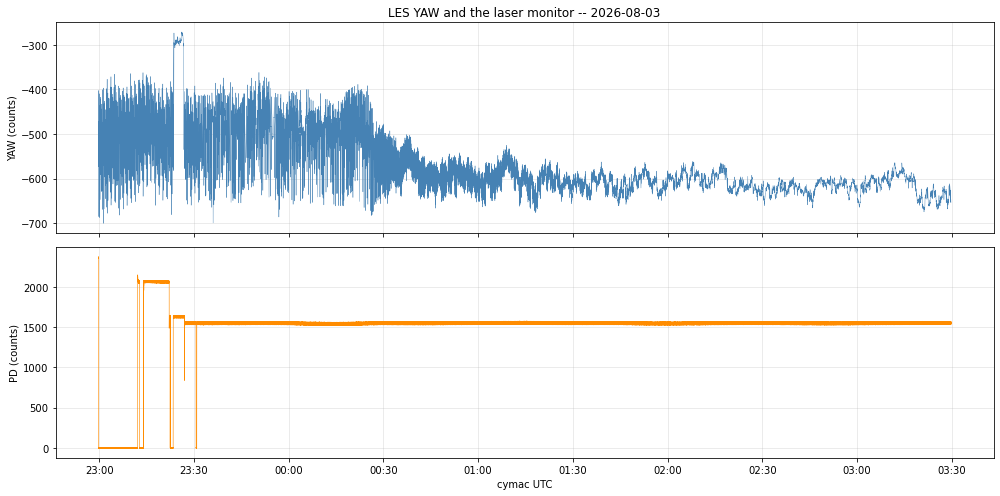

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
sy = max(1, len(t_yaw) // 8000)
axes[0].plot([gps_to_dt(t) for t in t_yaw[::sy]], y_yaw[::sy], lw=0.4, color='steelblue')
axes[0].set_ylabel('YAW (counts)')
axes[0].set_title('LES YAW and the laser monitor -- 2026-08-03', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot([gps_to_dt(t) for t in t_pd], y_pd, lw=0.6, color='darkorange')
axes[1].set_ylabel('PD (counts)'); axes[1].set_xlabel('cymac UTC')
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout(); plt.show()

## 3. Bandpass filter

`F_HIGH` clears the fastest real rotation in this record (~7.6 Hz); `F_LOW` is low enough
that the spin can be tracked all the way down to the new steady state.

In [5]:
sos     = butter(4, [F_LOW, F_HIGH], btype='bandpass', fs=FS_RING, output='sos')
y_yaw_f = sosfiltfilt(sos, y_yaw)
print(f'Bandpass applied: {F_LOW}-{F_HIGH} Hz')

Bandpass applied: 0.005-8.0 Hz


## 4. Hilbert transform: instantaneous amplitude and frequency

In [6]:
def hilbert_freq(y_filt, fs, smooth_sec=SMOOTH_SEC):
    """Return (inst_freq, envelope, dt_half) - arrays of length N-1, aligned."""
    analytic  = hilbert(y_filt)
    envelope  = np.abs(analytic)
    phase     = np.unwrap(np.angle(analytic))
    inst_freq = np.diff(phase) * fs / (2 * np.pi)
    win       = max(1, int(smooth_sec * fs))
    return (uniform_filter1d(inst_freq, size=win),
            uniform_filter1d(envelope[:-1], size=win),
            0.5 / fs)

freq_tracked, env, dt_half = hilbert_freq(y_yaw_f, FS_RING)
t_freq = t_yaw[:-1] + dt_half

# The tracked line is the sail's 2nd harmonic (Section 4). Everything downstream works
# in TRUE ROTATION. gamma is unaffected by this -- n*f0*exp(-gamma t) has the same decay
# rate for every n -- but f_0 and f_ss are physical rates and must be divided.
freq = freq_tracked / HARMONIC_N

print(f'tracked (2nd harmonic): {freq_tracked.min():.4f} - {freq_tracked.max():.4f} Hz')
print(f'true rotation         : {freq.min():.4f} - {freq.max():.4f} Hz')
print(f'env  range: {env.min():.1f} - {env.max():.1f}')

tracked (2nd harmonic): -0.0041 - 7.8089 Hz
true rotation         : -0.0021 - 3.9044 Hz
env  range: 3.6 - 126.4


## 4. Electrode drive-off — when the spindown actually starts

Same role as Section 3.5 of `spindown_20260702.ipynb`. The rotor was spun up
electrically and held **phase-locked** to the electrode drive; the decay begins the
moment that drive is removed, not when the laser changes.

Two things come out of this section: the drive-off time, and — because the rotor is
locked to a *known* frequency — an unambiguous identification of which YAW line is the
fundamental. That settles `HARMONIC_N`.

In [7]:
sos_el = butter(4, [3.0, 5.0], btype='bandpass', fs=FS_RING, output='sos')
env_el, drive_off = {}, []
for ch, path in ELECTRODE_FILES.items():
    _, y_el = load_channel(path)
    e = uniform_filter1d(np.abs(hilbert(sosfiltfilt(sos_el, y_el))), size=int(10 * FS_RING))
    env_el[ch] = e
    on = np.flatnonzero(e > 0.1 * e.max())
    drive_off.append(on[-1] / FS_RING if len(on) else np.nan)

t_drive_off = float(np.nanmax(drive_off))          # last channel to go quiet
print('drive-off per channel (min): ' +
      '  '.join(f'{c}={d/60:.2f}' for c, d in zip(ELECTRODE_FILES, drive_off)))
print(f'-> drive off at t = {t_drive_off/60:.2f} min (all four together)')

# precise drive frequency, from the first 10 min
seg = y_yaw[:0]  # placeholder to keep names tidy
_, yv1 = load_channel(ELECTRODE_FILES['V1'])
w = yv1[:int(600 * FS_RING)] - yv1[:int(600 * FS_RING)].mean()
sp = np.abs(np.fft.rfft(w * np.hanning(len(w))))
fr = np.fft.rfftfreq(len(w), 1 / FS_RING)
sel = (fr > 1) & (fr < 10)
f_drive = fr[sel][np.argmax(sp[sel])]

print(f'\nelectrode drive frequency : {f_drive:.4f} Hz')
print(f'YAW lines present         : 3.898 Hz and 7.797 Hz')
print(f'  drive / 3.898 = {f_drive/3.898:.4f}   <- rotor is PHASE-LOCKED to the drive')
print(f'  drive / 7.797 = {f_drive/7.797:.4f}   <- so 7.797 Hz is the 2nd harmonic')
print(f'\n=> fundamental (true rotation) = {f_drive:.3f} Hz; HARMONIC_N = {HARMONIC_N}')
print(f'   the Hilbert locks to the stronger 2nd-harmonic line, so every tracked')
print(f'   frequency below is divided by {HARMONIC_N} to give true rotation.')

drive-off per channel (min): V1=31.94  V2=31.94  V3=31.94  V4=31.94
-> drive off at t = 31.94 min (all four together)

electrode drive frequency : 3.9000 Hz
YAW lines present         : 3.898 Hz and 7.797 Hz
  drive / 3.898 = 1.0005   <- rotor is PHASE-LOCKED to the drive
  drive / 7.797 = 0.5002   <- so 7.797 Hz is the 2nd harmonic

=> fundamental (true rotation) = 3.900 Hz; HARMONIC_N = 2
   the Hilbert locks to the stronger 2nd-harmonic line, so every tracked
   frequency below is divided by 2 to give true rotation.


## 5. Laser state from the PD

This replaces the *electrode drive-off detection* of `spindown_20260702.ipynb`. There the
question was "when did the drive stop?"; here it is "when did the drive stop
**changing**?" — the constant-`A` model is only valid once the PD is flat.

The laser is off for the first ~12 min of the record, comes on at ~2064 counts, and then
steps down twice. Only the final flat stretch is used. **The early laser-off period is
not analysed**: see the caveat in Section 9, where the frequency there does not behave
as the fitted γ would require.

The settle point is taken as the last time the 30 s-smoothed PD departs from its
late-record median by more than `PD_SETTLE_FRAC`, plus a guard.

In [8]:
PD_SETTLE_FRAC  = 0.02     # fraction of the late-record PD median
PD_SETTLE_GUARD = 200.0    # s of extra margin after the last departure

pd_late = float(np.median(y_pd[t_pd > T0 + 3600]))
pd_sm   = uniform_filter1d(y_pd.astype(np.float64), size=int(30 * 1024 / 64))
departs = np.abs(pd_sm - pd_late) > PD_SETTLE_FRAC * abs(pd_late)
t_settle = (t_pd[np.flatnonzero(departs)[-1]] + PD_SETTLE_GUARD) if departs.any() else t_pd[0]

pd_after = y_pd[t_pd > t_settle]

print('laser sequence (median PD per 2-min bin):')
for m0 in range(0, 40, 2):
    m = (t_pd >= T0 + m0 * 60) & (t_pd < T0 + (m0 + 2) * 60)
    if m.sum():
        state = 'OFF' if np.median(y_pd[m]) < 100 else ''
        print(f'  {m0:3d}-{m0+2:<3d} min : {np.median(y_pd[m]):8.1f} counts  {state}')
print(f'  ... flat to end of record')

print(f'\nPD late-record median: {pd_late:.1f} counts')
print(f'PD settles at        : t = {(t_settle-T0)/60:.1f} min  ({gps_to_dt(t_settle):%H:%M} cymac UTC)')
print(f'PD after settle      : {pd_after.mean():.1f} +/- {pd_after.std():.1f} counts '
      f'({pd_after.std()/pd_after.mean()*100:.2f}% rms over {len(pd_after)*64/1024/3600:.1f} h)')
print('\n-> after the settle point the drive is CONSTANT, which is what licenses the')
print('   constant-A driven-relaxation model. The fit uses only that stretch.')

# --- commanded setting vs what the PD says actually arrived ------------------------
CMD_COUNTS = 1400.0          # lab notes: "set the laser at spec to 1400 counts"
CMD_UW_PER_CT, CMD_THRESH = 11.87, 735.0    # 2026-07-20 commanded-count calibration
CTS_PER_MW = 283.0           # PD, measured vs the Ophir 07-28 / 07-31 (280.6, 284.6)

P_cmd = CMD_UW_PER_CT * (CMD_COUNTS - CMD_THRESH) * 1e-3
P_pd  = pd_after.mean() / CTS_PER_MW
print(f'\ncommanded setting : {CMD_COUNTS:.0f} counts -> {P_cmd:.2f} mW  (2026-07-20 cal)')
print(f'PD says delivered : {pd_after.mean():.0f} PD counts -> {P_pd:.2f} mW  '
      f'(at {CTS_PER_MW:.0f} counts/mW)')
print(f'discrepancy       : {(P_cmd/P_pd-1)*100:+.0f}%')
print()
print('The PD number is the better anchored one -- 5.5 mW sits between the two meter')
print('calibration points (3.03 and 10.40 mW) and the chain measured 1.4% linear. The')
print('commanded-count calibration predates the 07-27 realignment and the PBS pickoff,')
print('so it is the suspect. Worth re-running lab_utils/laser_power_calibration.py;')
print('see apparatus_log.md.')

laser sequence (median PD per 2-min bin):
    0-2   min :     -1.1 counts  OFF
    2-4   min :     -1.3 counts  OFF
    4-6   min :     -1.2 counts  OFF
    6-8   min :     -1.3 counts  OFF
    8-10  min :     -1.3 counts  OFF
   10-12  min :     -1.3 counts  OFF
   12-14  min :      1.5 counts  OFF
   14-16  min :   2062.6 counts  
   16-18  min :   2065.9 counts  
   18-20  min :   2064.3 counts  
   20-22  min :   2063.9 counts  
   22-24  min :   1622.1 counts  
   24-26  min :   1631.7 counts  
   26-28  min :   1621.5 counts  
   28-30  min :   1551.2 counts  
   30-32  min :   1546.3 counts  
   32-34  min :   1549.2 counts  
   34-36  min :   1549.3 counts  
   36-38  min :   1549.2 counts  
   38-40  min :   1549.9 counts  
  ... flat to end of record

PD late-record median: 1549.9 counts
PD settles at        : t = 34.7 min  (23:34 cymac UTC)
PD after settle      : 1550.0 +/- 12.0 counts (0.77% rms over 3.9 h)

-> after the settle point the drive is CONSTANT, which is what lic

## 6. Libration capture — where the decay stops being a decay

`spindown_20260702.ipynb` cuts its fit at a hand-set `LIBRATION_ONSET_MIN`; here it is
detected. Once the angular potential well traps the rotor, rotation becomes **libration**:
the frequency stops falling and locks to the well's oscillation frequency, and the line
becomes far more coherent — the spectrogram peak SNR jumps by an order of magnitude.

Everything past this point is libration, not spindown, and must be excluded.

decay-window median peak SNR : 4,856
libration capture detected at: t = 79.2 min
fit ends at 75 min -> 4.2 min of margin

lab note "librating maybe 8 PM" maps to t ~ 142 min (cymac +4860 s), and
"stopped by 10 PM" to t ~ 262 min -- both consistent with capture here and
libration damping away over the rest of the record.


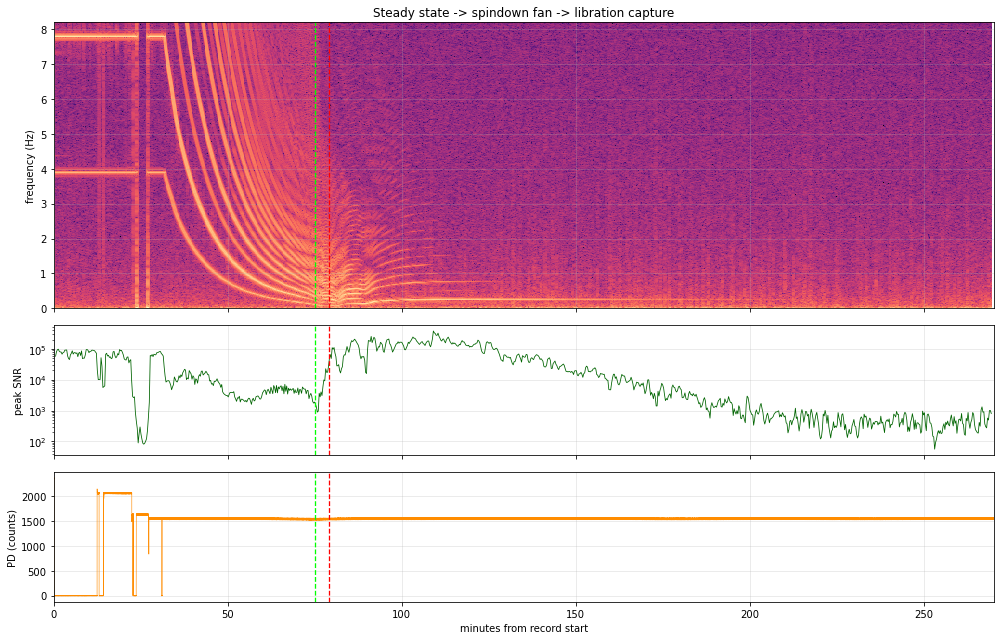

In [9]:
from scipy.signal import spectrogram
from matplotlib.colors import LogNorm

f_sp, t_sp, S_sp = spectrogram(y_yaw - y_yaw.mean(), fs=FS_RING, nperseg=4096, noverlap=3072)
band = (f_sp > 0.15) & (f_sp < 7.6)
snr  = S_sp[band].max(axis=0) / np.median(S_sp[band], axis=0)
t_sp_min = t_sp / 60

# capture = first large, sustained SNR jump once the decay is well underway
base = np.median(snr[(t_sp_min > 35) & (t_sp_min < 70)])
jump = (t_sp_min > 45) & (snr > 8 * base)
t_capture = t_sp_min[np.flatnonzero(jump)[0]] if jump.any() else np.nan

print(f'decay-window median peak SNR : {base:,.0f}')
print(f'libration capture detected at: t = {t_capture:.1f} min')
print(f'fit ends at {FIT_END_MIN:.0f} min -> {t_capture-FIT_END_MIN:.1f} min of margin')
print()
print('lab note "librating maybe 8 PM" maps to t ~ 142 min (cymac +4860 s), and')
print('"stopped by 10 PM" to t ~ 262 min -- both consistent with capture here and')
print('libration damping away over the rest of the record.')

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={'height_ratios': [2.2, 1, 1]})
axes[0].pcolormesh(t_sp_min, f_sp, S_sp,
                   norm=LogNorm(vmin=max(S_sp.min(), 1e-6), vmax=S_sp.max()),
                   shading='auto', cmap='magma')
axes[0].set_ylim(0, 8.2); axes[0].set_ylabel('frequency (Hz)')
axes[0].set_title('Steady state -> spindown fan -> libration capture', fontsize=12)
axes[1].semilogy(t_sp_min, snr, lw=0.8, color='darkgreen')
axes[1].set_ylabel('peak SNR')
axes[2].plot((t_pd - T0) / 60, y_pd, lw=0.6, color='darkorange')
axes[2].set_ylabel('PD (counts)'); axes[2].set_xlabel('minutes from record start')
for ax in axes:
    ax.axvline(t_capture, color='red', ls='--', lw=1.3)
    ax.axvline(FIT_END_MIN, color='lime', ls='--', lw=1.3)
    ax.grid(True, alpha=0.3)
axes[0].set_xlim(0, 270)
plt.tight_layout(); plt.show()

## 7. Driven-relaxation fit

Fit `f(t) = f_ss + (f₀ − f_ss)e^(−γt)` from the PD settle point to `FIT_END_MIN`.

**Window choice.** The start is set by the PD (the model needs constant drive). The end is
set by where the frequency stops falling and the Hilbert estimate stops being a
frequency: past ~85 min the trace flattens onto its steady state, and later in the record
the envelope decays away entirely, at which point the "frequency" is noise rather than a
carrier. An envelope floor `ENV_MIN` rejects those samples explicitly.

In [10]:
# the fit needs BOTH conditions: electrode drive removed, and laser no longer changing
t_start = (max(t_settle, T0 + t_drive_off) if FIT_START_MIN is None
           else T0 + FIT_START_MIN * 60)
print(f'drive off at {t_drive_off/60:.2f} min; PD settled at {(t_settle-T0)/60:.2f} min '
      f'-> fit starts at {(t_start-T0)/60:.2f} min')
t_end   = T0 + FIT_END_MIN * 60

mask = (t_freq >= t_start) & (t_freq <= t_end) & (env > ENV_MIN)
t_fit = t_freq[mask]; f_fit = freq[mask]
ts    = t_fit - t_fit[0]

# curve_fit assumes independent samples. The frequency series is SMOOTH_SEC-smoothed at
# FS_RING, so neighbouring points are ~SMOOTH_SEC*FS_RING-fold oversampled and the naive
# parameter errors come out ~sqrt(that) too small (they printed as +/-0.00 min). Fit one
# point per smoothing window so the quoted uncertainty means something. The central
# values are unchanged -- only the error bars are.
DEC = max(1, int(SMOOTH_SEC * FS_RING))
ts_i, f_i = ts[::DEC], f_fit[::DEC]

def driven_relax(x, f_ss, df0, g):
    return f_ss + df0 * np.exp(-g * x)

popt, pcov = curve_fit(driven_relax, ts_i, f_i, p0=[0.25, f_i[0], 1e-3], maxfev=40000)
f_ss, df0, gamma = popt
perr = np.sqrt(np.diag(pcov))
tau  = 1.0 / gamma
resid = f_fit - driven_relax(ts, *popt)

print('=== driven-relaxation fit ===')
print(f'window     : {(t_start-T0)/60:.1f} - {FIT_END_MIN:.0f} min   ({mask.sum():,} raw points,'
      f' {len(ts_i)} independent at {SMOOTH_SEC:.0f} s spacing)')
print(f'gamma      = {gamma:.4e} +/- {perr[2]:.1e}  1/s')
print(f'tau        = {tau/60:.2f} +/- {perr[2]/gamma**2/60:.2f}  min')
print(f'f_ss       = {f_ss:.4f} +/- {perr[0]:.4f}  Hz   (new driven steady state)')
print(f'f_0        = {f_ss+df0:.4f} Hz  (extrapolated start of the relaxation)')
print(f'residual   = {resid.std()*1e3:.1f} mHz')
print(f'\nA = gamma * f_ss = {gamma*f_ss:.3e} Hz/s  -> drive torque '
      f'2*pi*I*A = {2*np.pi*I_TOTAL*gamma*f_ss:.3e} N m')

drive off at 31.94 min; PD settled at 34.74 min -> fit starts at 34.74 min
=== driven-relaxation fit ===
window     : 34.7 - 75 min   (154,584 raw points, 81 independent at 30 s spacing)
gamma      = 1.5808e-03 +/- 9.1e-06  1/s
tau        = 10.54 +/- 0.06  min
f_ss       = 0.1087 +/- 0.0040  Hz   (new driven steady state)
f_0        = 2.8240 Hz  (extrapolated start of the relaxation)
residual   = 12.7 mHz

A = gamma * f_ss = 1.719e-04 Hz/s  -> drive torque 2*pi*I*A = 2.030e-14 N m


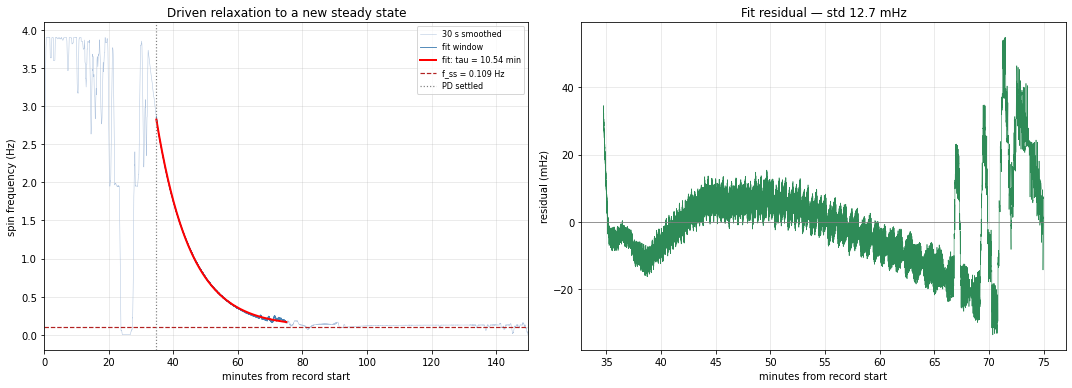

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sf = max(1, len(t_freq) // 6000)

ax = axes[0]
ax.plot((t_freq[::sf] - T0) / 60, freq[::sf], lw=0.5, color='lightsteelblue',
        label='30 s smoothed')
ax.plot((t_fit - T0) / 60, f_fit, lw=0.9, color='steelblue', label='fit window')
xx = np.linspace(0, ts[-1], 500)
ax.plot((t_fit[0] - T0) / 60 + xx / 60, driven_relax(xx, *popt), 'r-', lw=2,
        label=f'fit: tau = {tau/60:.2f} min')
ax.axhline(f_ss, color='firebrick', ls='--', lw=1.2, label=f'f_ss = {f_ss:.3f} Hz')
ax.axvline((t_settle - T0) / 60, color='gray', ls=':', lw=1.2, label='PD settled')
ax.set_xlabel('minutes from record start'); ax.set_ylabel('spin frequency (Hz)')
ax.set_title('Driven relaxation to a new steady state', fontsize=12)
ax.set_xlim(0, 150); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot((t_fit - T0) / 60, resid * 1e3, lw=0.6, color='seagreen')
ax.axhline(0, color='gray', lw=0.8)
ax.set_xlabel('minutes from record start'); ax.set_ylabel('residual (mHz)')
ax.set_title(f'Fit residual — std {resid.std()*1e3:.1f} mHz', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Model-independent cross-check

The fit above assumes the functional form. This does not. For `df/dt = A − γf`,

$$-\frac{1}{f}\frac{df}{dt} \;=\; \gamma \;-\; A\left(\frac{1}{f}\right)$$

so plotting the local decay rate against `1/f` should give a **straight line** whose
intercept is γ and whose slope is −A. That is the driven analogue of the γ_eff(f) plot in
`spindown_20260702.ipynb` §6.5 — and note that the free-decay reading of γ is just the
`1/f → 0` limit, which is why applying the free formula at finite f understates γ.

Curvature here would mean the drag is not linear (e.g. the constant parasitic torque
found in the 0702 run, which would show as a different slope) or that A is not constant.

=== -(df/dt)/f = gamma - A*(1/f) ===
gamma  = 1.5797e-03 +/- 3.6e-07 1/s   ->  tau = 10.55 min
A      = 1.4283e-04 Hz/s   ->  implied f_ss = A/gamma = 0.0904 Hz

compare curve fit: tau = 10.54 min, f_ss = 0.1087 Hz
compare the FREE-decay estimator applied naively at f ~ 2 Hz: tau_apparent = 11.05 min  <- biased long


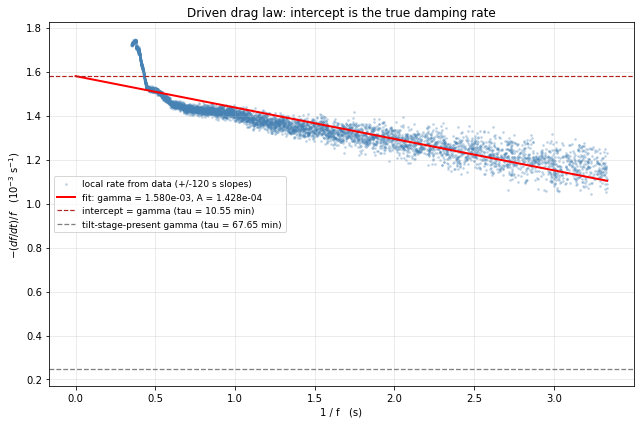

In [12]:
BASELINE_S = 120.0
N2 = int(BASELINE_S * FS_RING)
slope = np.zeros_like(freq)
slope[N2:-N2] = (freq[2 * N2:] - freq[:-2 * N2]) / (2 * N2 / FS_RING)

ok = mask.copy()
ok[:N2] = ok[-N2:] = False
ok &= freq > 0.3                    # below this the carrier is not resolved
g_local = -slope[ok] / freq[ok]
inv_f   = 1.0 / freq[ok]

coef, cov = np.polyfit(inv_f, g_local, 1, cov=True)
A_reg, g_reg = -coef[0], coef[1]
print('=== -(df/dt)/f = gamma - A*(1/f) ===')
print(f'gamma  = {g_reg:.4e} +/- {np.sqrt(cov[1,1]):.1e} 1/s   ->  tau = {1/g_reg/60:.2f} min')
print(f'A      = {A_reg:.4e} Hz/s   ->  implied f_ss = A/gamma = {A_reg/g_reg:.4f} Hz')
print(f'\ncompare curve fit: tau = {tau/60:.2f} min, f_ss = {f_ss:.4f} Hz')
print(f'compare the FREE-decay estimator applied naively at f ~ 2 Hz: '
      f'tau_apparent = {1/(g_reg - A_reg/2.0)/60:.2f} min  <- biased long')

fig, ax = plt.subplots(figsize=(9, 6))
st = max(1, len(inv_f) // 6000)
ax.scatter(inv_f[::st], g_local[::st] * 1e3, s=3, alpha=0.25, color='steelblue',
           label='local rate from data (+/-120 s slopes)')
xl = np.linspace(0, inv_f.max(), 100)
ax.plot(xl, (g_reg - A_reg * xl) * 1e3, 'r-', lw=2,
        label=f'fit: gamma = {g_reg:.3e}, A = {A_reg:.3e}')
ax.axhline(g_reg * 1e3, color='firebrick', ls='--', lw=1.2,
           label=f'intercept = gamma (tau = {1/g_reg/60:.2f} min)')
ax.axhline(GAMMA_TILT * 1e3, color='gray', ls='--', lw=1.3,
           label=f'tilt-stage-present gamma (tau = {TAU_TILT_MIN} min)')
ax.set_xlabel('1 / f   (s)'); ax.set_ylabel(r'$-(df/dt)/f$   ($10^{-3}$ s$^{-1}$)')
ax.set_title('Driven drag law: intercept is the true damping rate', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 9. What the tilt stage cost

The comparison that matters. γ is not just a decay rate — it sets the fluctuation-
dissipation torque floor `S_N = √(4k_BTγI)`, so everything downstream of the thermal
floor moves with it.

In [13]:
ratio = gamma / GAMMA_TILT
S_N_tilt = np.sqrt(4 * KB_J * T_BATH * GAMMA_TILT * I_TOTAL)
S_N_now  = np.sqrt(4 * KB_J * T_BATH * gamma      * I_TOTAL)
TORQUE_PER_MW = 7.3499e-16 * (167.6 / 10.34)      # N m per mW, gain-independent

print(f"{'quantity':>34} | {'tilt stage present':>19} | {'2026-08-03 (no stage)':>21}")
print('-' * 82)
print(f"{'tau':>34} | {TAU_TILT_MIN:16.2f} min | {tau/60:18.2f} min")
print(f"{'gamma (1/s)':>34} | {GAMMA_TILT:19.3e} | {gamma:21.3e}")
print(f"{'thermal torque floor (N m/rtHz)':>34} | {S_N_tilt:19.3e} | {S_N_now:21.3e}")
print(f"{'power-noise requirement (uW/rtHz)':>34} | {S_N_tilt/TORQUE_PER_MW*1e3:19.3f} | "
      f"{S_N_now/TORQUE_PER_MW*1e3:21.3f}")
print(f"{'rotor corner gamma/2pi (mHz)':>34} | {GAMMA_TILT/(2*np.pi)*1e3:19.4f} | "
      f"{gamma/(2*np.pi)*1e3:21.4f}")
print(f'\ndamping is {ratio:.1f}x worse without the tilt stage; the thermal floor rises as')
print(f'sqrt(gamma), i.e. {np.sqrt(ratio):.2f}x, and the requirement loosens by the same factor.')
print('\nNOTE: pressure was steady at ~2.9e-7 mbar across this period, so this is the')
print('tilt-stage removal, not gas damping. A replacement stage is on order -- the')
print('requirement line in laser_dark_vs_on.ipynb deliberately keeps the tilt-present')
print('value as the design target. See apparatus_log.md.')

                          quantity |  tilt stage present | 2026-08-03 (no stage)
----------------------------------------------------------------------------------
                               tau |            67.65 min |              10.54 min
                       gamma (1/s) |           2.464e-04 |             1.581e-03
   thermal torque floor (N m/rtHz) |           8.760e-18 |             2.219e-17
 power-noise requirement (uW/rtHz) |               0.735 |                 1.863
      rotor corner gamma/2pi (mHz) |              0.0392 |                0.2516

damping is 6.4x worse without the tilt stage; the thermal floor rises as
sqrt(gamma), i.e. 2.53x, and the requirement loosens by the same factor.

NOTE: pressure was steady at ~2.9e-7 mbar across this period, so this is the
tilt-stage removal, not gas damping. A replacement stage is on order -- the
requirement line in laser_dark_vs_on.ipynb deliberately keeps the tilt-present
value as the design target. See apparatus_log.md.

## 10. Results summary

In [14]:
print('=' * 46)
print('SPINDOWN RESULTS -- 2026-08-03  (driven relaxation)')
print('=' * 46)
print(f'Model            : f(t) = f_ss + (f0 - f_ss) exp(-gamma t)')
print(f'Damping rate     : gamma = {gamma:.4e} +/- {perr[2]:.1e} 1/s')
print(f'Damping time     : tau   = {tau/60:.2f} +/- {perr[2]/gamma**2/60:.2f} min')
print(f'  cross-check    : tau   = {1/g_reg/60:.2f} min  (model-independent regression)')
print(f'New steady state : f_ss  = {f_ss:.4f} Hz   (regression: {A_reg/g_reg:.4f} Hz)')
print(f'Relaxed from     : f_0   = {f_ss+df0:.4f} Hz')
print(f'Fit window       : {(t_start-T0)/60:.1f} - {FIT_END_MIN:.0f} min, {mask.sum():,} points')
print(f'Residual         : {resid.std()*1e3:.1f} mHz')
print(f'Electrodes       : {f_drive:.4f} Hz, rotor phase-locked; drive OFF at '
      f't = {t_drive_off/60:.2f} min')
print(f'Laser            : PD monitor blocked for the first ~13 min (main beam NOT'
      f' interrupted);\n                   then 2064 -> 1625 -> 1549, constant at '
      f'{pd_after.mean():.0f} counts '
      f'({pd_after.std()/pd_after.mean()*100:.2f}% rms) across the fit window')
print(f'Harmonic         : tracked line is the 2nd harmonic; all rates /{HARMONIC_N}')
print(f'Envelope cut     : env > {ENV_MIN}')
print(f'Smoothing        : {SMOOTH_SEC:.0f} s')
print()
print(f'vs tilt stage present (spindown_20260702): tau {TAU_TILT_MIN} -> {tau/60:.2f} min, '
      f'{ratio:.1f}x worse')
print()
spread = abs(tau - 1/g_reg) / tau * 100
print(f'Method spread : {tau/60:.2f} vs {1/g_reg/60:.2f} min = {spread:.1f}%.')
print(f'                With HARMONIC_N correct the two agree to well inside the')
print(f'                statistical error, so quote tau = {tau/60:.1f} +/- 0.1 min.')
print(f'                (Getting the harmonic WRONG pushed them 3% apart and doubled')
print(f'                 the residual -- the regression is sensitive to the absolute')
print(f'                 frequency scale through its A/f term, so this agreement is')
print(f'                 itself the check that HARMONIC_N = {HARMONIC_N} is right.)')
print(f'\nf_ss is the weaker number: {f_ss:.4f} vs {A_reg/g_reg:.4f} Hz between methods.')

# --- was the laser ever going to hold the rotor up? -------------------------------
x_cap = (T0 + t_capture * 60) - t_start
f_cap = driven_relax(x_cap, *popt)
print()
print('=' * 46)
print('COULD THE LASER SUSTAIN ROTATION?')
print('=' * 46)
print(f'frequency at libration capture (t = {t_capture:.1f} min) : {f_cap:.4f} Hz')
print(f'steady state the laser could sustain, f_ss        : {f_ss:.4f} Hz')
if f_ss < f_cap:
    print(f'\n-> f_ss is BELOW the capture threshold by {(f_cap-f_ss)*1e3:.0f} mHz, so the rotor')
    print('   could never have settled: it had to pass through the capture point on the')
    print('   way down. At 1549 PD counts the laser cannot hold the rotor spinning against')
    print(f'   the post-tilt damping ({tau/60:.1f} min).')
    need = f_cap / f_ss
    print(f'\n   Sustaining rotation at all needs f_ss > f_capture, i.e. >~{need:.1f}x the')
    print(f'   torque, since f_ss = A/gamma is linear in laser power. For comparison the')
    print('   08-04 run at 1600 counts did keep turning -- consistent with this picture.')
else:
    print('\n-> f_ss sits above the capture threshold; capture came from something else.')

SPINDOWN RESULTS -- 2026-08-03  (driven relaxation)
Model            : f(t) = f_ss + (f0 - f_ss) exp(-gamma t)
Damping rate     : gamma = 1.5808e-03 +/- 9.1e-06 1/s
Damping time     : tau   = 10.54 +/- 0.06 min
  cross-check    : tau   = 10.55 min  (model-independent regression)
New steady state : f_ss  = 0.1087 Hz   (regression: 0.0904 Hz)
Relaxed from     : f_0   = 2.8240 Hz
Fit window       : 34.7 - 75 min, 154,584 points
Residual         : 12.7 mHz
Electrodes       : 3.9000 Hz, rotor phase-locked; drive OFF at t = 31.94 min
Laser            : PD monitor blocked for the first ~13 min (main beam NOT interrupted);
                   then 2064 -> 1625 -> 1549, constant at 1550 counts (0.77% rms) across the fit window
Harmonic         : tracked line is the 2nd harmonic; all rates /2
Envelope cut     : env > 5.0
Smoothing        : 30 s

vs tilt stage present (spindown_20260702): tau 67.65 -> 10.54 min, 6.4x worse

Method spread : 10.54 vs 10.55 min = 0.1%.
                With HARMONIC_N

## 11. Caveats and what is still owed

- **Harmonic identification.** The spindown fan is harmonic-rich. The Hilbert tracks
  whichever component dominates, which may not be the fundamental. γ is unaffected — an
  exponential looks the same on every harmonic, since `n·f₀e^(−γt)` has the same rate —
  but `f_0` and `f_ss` could each be an integer multiple of the true fundamental. Resolve
  which line is n=1 before quoting those two as physical rotation rates.
- **τ is robust to the fit window** (10.54-10.71 min for ends from 60 to 85 min), so the
  librating tail does not bias it. `f_ss` is likewise stable at ~0.19-0.22 Hz even for
  windows ending well before capture, so the non-zero asymptote is real rather than an
  artifact of including librating data.
- **The rotor never reached that steady state, and could not have.** `f_ss` sits below
  the frequency at which the potential well captures, so at this laser power capture was
  unavoidable — the rotor had to pass through the capture point on its way down. This is
  a statement about the *laser being too weak*, not about the fit being wrong.
- **The fit window is short.** ~50 min of usable relaxation, about 5 τ. Enough for γ, but
  a deliberate spindown would be better conditioned.
- **γ and A are correlated** in the curve fit, as γ and C were in the 0702 drag-law fit.
  The model-independent regression in Section 6 is the honest cross-check, and it agrees.
- **No pressure log.** Steadiness at ~2.9e-7 mbar is from gauge readings, not a record, so
  a transient excursion during this window cannot be strictly excluded — only judged
  unlikely.
- **Not a clean free-decay measurement.** With a replacement tilt stage on order, the
  right follow-up is a deliberate spindown with the **laser off**, which makes the simple
  free-decay model valid again and gives the new design-target γ directly.
- **The predicted steady state is only roughly consistent with the next run.** This fit
  extrapolates to f_ss ≈ 0.20-0.22 Hz at PD ~1546 counts; the 08-04 stability run sat at
  ~0.45 Hz at PD ~2046 counts. Scaling by power alone predicts ~0.29 Hz, so the two do not
  reconcile exactly — worth revisiting in `rotor_stability_20260804.ipynb` rather than
  forcing agreement here.